# **Exploratory Data Analysis**

In [1]:
import os
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

from pathlib import Path

import torch
from torchvision import transforms, datasets
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import warnings
warnings.filterwarnings("ignore")

BATCH_SIZE = 32

DATA_DIR = Path("../data")
TRAIN_DIR = DATA_DIR / "train"
VALID_DIR = DATA_DIR / "valid"
TEST_DIR = DATA_DIR / "test"

SEED = 42

# setting random seeds for reprodicibilty
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

normalization mean and std is available on https://www.kaggle.com/datasets/mengcius/cinic10

cinic_mean_RGB = [0.47889522, 0.47227842, 0.43047404]

cinic_std_RGB = [0.24205776, 0.23828046, 0.25874835]

this will be used in preprocessing steps

In [2]:
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(), # -> normalized pixels to [0,1], possible to add standardization
])

In [3]:
train_ds = datasets.ImageFolder(
    root=TRAIN_DIR,
    transform=transform,
)

valid_ds = datasets.ImageFolder(
    root=VALID_DIR,
    transform=transform,
)

test_ds = datasets.ImageFolder(
    root=TEST_DIR,
    transform=transform,
)

In [4]:
train_loader = torch.utils.data.DataLoader(
    dataset=train_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

valid_loader = torch.utils.data.DataLoader(
    dataset=valid_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

test_loader = torch.utils.data.DataLoader(
    dataset=test_ds,
    batch_size=BATCH_SIZE,
    shuffle=True,
)

In [5]:
images, labels = next(iter(train_loader))
print(images.shape)
print(labels.shape)

torch.Size([32, 3, 224, 224])
torch.Size([32])


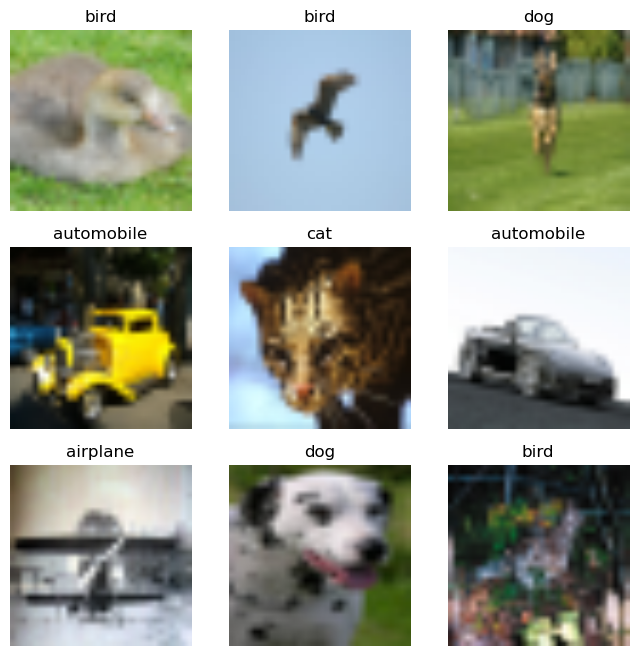

In [6]:
indexes = np.random.choice(len(images), size=9, replace=False)
class_names = train_ds.classes

plt.figure(figsize=(8, 8))
for i, idx in enumerate(indexes):
    plt.subplot(3, 3, i+1)
    img = images[idx].permute(1, 2, 0)
    plt.imshow(img)
    plt.title(class_names[labels[idx]])
    plt.axis("off")

plt.show()

In [7]:
num_classes = len(train_ds.classes)
print(f"Number of classes: {num_classes}")
print("Class names:", train_ds.classes)

Number of classes: 10
Class names: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']


In [9]:
num_train = len(train_ds)
num_valid = len(valid_ds)
num_test  = len(test_ds)

print(f"Number of images in train: {num_train}")
print(f"Number of images in valid: {num_valid}")
print(f"Number of images in test : {num_test}")

total_images = num_train + num_valid + num_test
print(f"Total number of images: {total_images}")

Number of images in train: 90000
Number of images in valid: 90000
Number of images in test : 90000
Total number of images: 270000
